In [1]:
print("hello world")

hello world


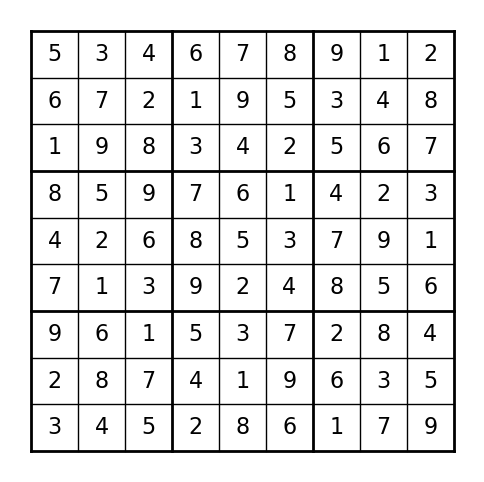

In [12]:
import pandas as pd
import gurobipy as gp
import matplotlib.pyplot as plt

# Data
# 读取 Excel 文件
df = pd.read_excel("/Users/linus/PycharmProjects/scientificProject_operation_research_class/data/sudoku_test.xlsx", header=None)


# Model
model = gp.Model("Sudoku")
model.setParam('OutputFlag', 0)  # 不显示求解日志

# 创建变量 x[i,j,k] = 1 表示在格子(i,j)上填数字 k+1
x = model.addVars(9, 9, 9, vtype=gp.GRB.BINARY, name="x")

# 约束 1：每个格子只能填一个数
for i in range(9):
    for j in range(9):
        model.addConstr(gp.quicksum(x[i, j, k] for k in range(9)) == 1)

# 约束 2：每行每个数字只能出现一次
for i in range(9):
    for k in range(9):
        model.addConstr(gp.quicksum(x[i, j, k] for j in range(9)) == 1)

# 约束 3：每列每个数字只能出现一次
for j in range(9):
    for k in range(9):
        model.addConstr(gp.quicksum(x[i, j, k] for i in range(9)) == 1)

# 约束 4：每个3x3小宫格每个数字只能出现一次
for block_i in range(3):
    for block_j in range(3):
        for k in range(9):
            model.addConstr(gp.quicksum(
                x[i, j, k]
                for i in range(block_i * 3, block_i * 3 + 3)
                for j in range(block_j * 3, block_j * 3 + 3)
            ) == 1)

# 约束 5：已有数字（从Excel中读取）
for i in range(9):
    for j in range(9):
        value = df.iloc[i, j]
        if pd.notna(value) and int(value) != 0:
            k = int(value) - 1  # Gurobi变量的索引是 0~8，表示数值1~9
            model.addConstr(x[i, j, k] == 1)

# 目标函数（没有目标，只是找一个可行解）
model.setObjective(0, gp.GRB.MINIMIZE)


# Solve
model.optimize()

# 获取解（9x9 的 list）
solution = []
if model.status == gp.GRB.OPTIMAL:
    for i in range(9):
        row = []
        for j in range(9):
            for k in range(9):
                if x[i, j, k].X > 0.9:
                    row.append(k + 1)
                    break
        solution.append(row)
else:
    solution = None

# 打印解
def visualize_sudoku(solution):
    fig, ax = plt.subplots(figsize=(6,6))
    # 画网格线
    for i in range(10):
        lw = 2 if i % 3 == 0 else 1
        ax.plot([0, 9], [i, i], color='black', linewidth=lw)
        ax.plot([i, i], [0, 9], color='black', linewidth=lw)

    # 写数字，文本坐标改为 (j+0.5, i+0.5)
    for i in range(9):
        for j in range(9):
            ax.text(j + 0.5, i + 0.5, str(solution[i][j]), ha='center', va='center', fontsize=16)

    ax.axis('off')
    plt.gca().invert_yaxis()  # 反转y轴，使第一行在顶部
    plt.show()

# 调用示例
visualize_sudoku(solution)
